### Step 1: Load the Data into a PySpark DataFrame

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("SalesAnalysis").getOrCreate()

# Load sales data from a CSV file
sales_df = spark.read.csv("sales_data.csv", header=True, inferSchema=True)

# Display the schema and first few records
sales_df.printSchema()
sales_df.show(5)

root
 |-- customer_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- customer_email: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- product_price: double (nullable = true)
 |-- sale_id: integer (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- sale_date: date (nullable = true)

+-----------+-------------+--------------------+----------+---------------+-------------+-------+--------+----------+
|customer_id|customer_name|      customer_email|product_id|   product_name|product_price|sale_id|quantity| sale_date|
+-----------+-------------+--------------------+----------+---------------+-------------+-------+--------+----------+
|       1001|   John Smith|john.smith@email.com|      1234|T-Shirt (Large)|        19.99|  98765|       2|2024-05-14|
|       1002|     Jane Doe|  jane.doe@email.com|      4567|         Laptop|       899.99|  12345|       1|2024-05-13|
|       1003|  Mi

### Step 2: Clean and Preprocess the Data

In [2]:
# Filter out rows that contain null values in critical columns
NoNull_df = sales_df.filter(sales_df["customer_id"].isNotNull() & sales_df["product_id"].isNotNull() & sales_df["product_price"].isNotNull())

# Remove any duplicate entries based on sale_id
cleaned_df = NoNull_df.dropDuplicates(["sale_id"])


### Step 3: Register the Cleaned DataFrame as a Temporary SQL Table

In [3]:
cleaned_df.createOrReplaceTempView("sales_table")

### Step 4: Analyze Total Revenue per Product and Identify the Top 5 Products by Type for Particular Parameters

In [4]:
top_5_products = spark.sql("""
SELECT product_name, SUM(product_price * quantity) AS total_revenue
FROM sales_table
WHERE product_name LIKE '%Gaming%' 
                           OR product_name LIKE '%Desk%'
GROUP BY product_name
ORDER BY total_revenue DESC
LIMIT 5
""")
top_5_products.show()

+--------------+-------------+
|  product_name|total_revenue|
+--------------+-------------+
|Gaming Headset|        99.99|
|  Gaming Mouse|        99.98|
|     Desk Lamp|        99.96|
|Desk Organizer|        59.96|
+--------------+-------------+



### Step 5: Visualize the Top 5 Gaming and Desk-Related Products by Revenue

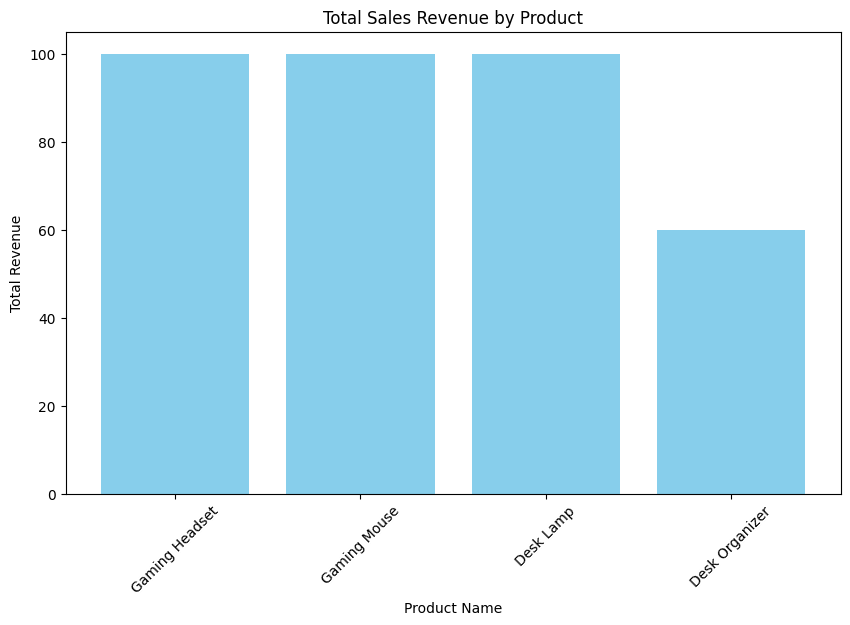

In [6]:
products = top_5_products.select("product_name").rdd.flatMap(lambda x: x).collect()

revenue = top_5_products.select("total_revenue").rdd.flatMap(lambda x: x).collect()

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(products, revenue, color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Total Revenue')
plt.title('Total Sales Revenue by Product')
plt.xticks(rotation=45)
plt.show()

### Step 6: Identify the Top 3 Customers by Total Spending

In [7]:
top_3_customers = spark.sql("""
SELECT customer_name, customer_email, SUM(product_price * quantity) AS total_spent
FROM sales_table
GROUP BY customer_name, customer_email
ORDER BY total_spent DESC
LIMIT 3
""")
top_3_customers.show()

+-------------+--------------------+-----------+
|customer_name|      customer_email|total_spent|
+-------------+--------------------+-----------+
|     Jane Doe|  jane.doe@email.com|     899.99|
|  Ryan Walker|ryan.walker@email...|     599.98|
|Sophia Taylor|sophia.taylor@ema...|     499.98|
+-------------+--------------------+-----------+



### Step 7: Analyze Average Revenue per Sale for Each Product

In [8]:
average_revenue_per_product = spark.sql("""
SELECT product_name, AVG(product_price * quantity) AS avg_revenue
FROM sales_table
GROUP BY product_name
ORDER BY avg_revenue DESC
""")
average_revenue_per_product.show()

+-------------------+------------------+
|       product_name|       avg_revenue|
+-------------------+------------------+
|             Laptop|            899.99|
|        Camera Lens|           449.985|
|         Smartwatch|            399.98|
|             Tablet|           374.985|
|          Projector|            349.99|
|              Watch|           299.985|
|       Air Purifier|           194.985|
|Wireless Headphones|            149.98|
|           Backpack|           124.975|
|     Gaming Headset|             99.99|
|       Gaming Mouse|             99.98|
|         Headphones|             99.98|
|   Wireless Speaker|             79.99|
|    Fitness Tracker|            59.985|
|           Yoga Mat|            52.485|
|          Desk Lamp|             49.98|
|   Portable Charger|49.974999999999994|
|     Protein Powder|              49.9|
|    T-Shirt (Large)|             39.98|
|           Notebook|             39.96|
+-------------------+------------------+
only showing top

### Step 8: Visualize Average Revenue per Sale for Top 10 Product

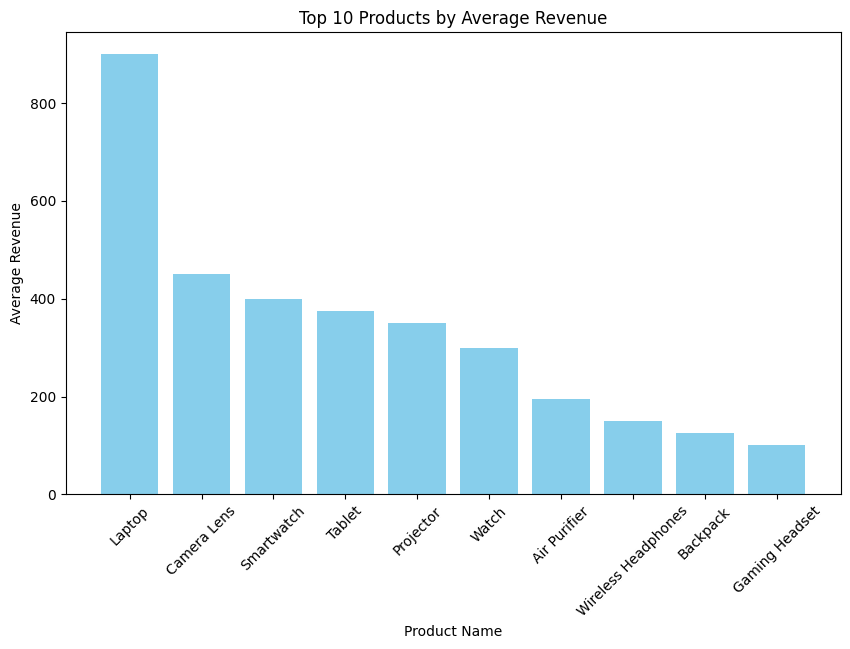

In [9]:
top_10_products = average_revenue_per_product.limit(10)
products = top_10_products.select("product_name").rdd.flatMap(lambda x: x).collect()
average_revenue = top_10_products.select("avg_revenue").rdd.flatMap(lambda x: x).collect()

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(products, average_revenue, color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Average Revenue')
plt.title('Top 10 Products by Average Revenue')
plt.xticks(rotation=45)
plt.show()


### Step 9: Identify the Most Popular Products by Quantity Sold

In [10]:
top_5_most_popular_products = spark.sql("""
SELECT product_name, SUM(quantity) AS total_quantity
FROM sales_table
GROUP BY product_name
ORDER BY total_quantity DESC
LIMIT 5
""")
top_5_most_popular_products.show()

+--------------------+--------------+
|        product_name|total_quantity|
+--------------------+--------------+
|          Travel Mug|             6|
|    Portable Charger|             5|
|            Backpack|             5|
|Water Bottle (Large)|             4|
|            Notebook|             4|
+--------------------+--------------+



### Step 10: Visualize the Top 5 Products by Quantity Sold

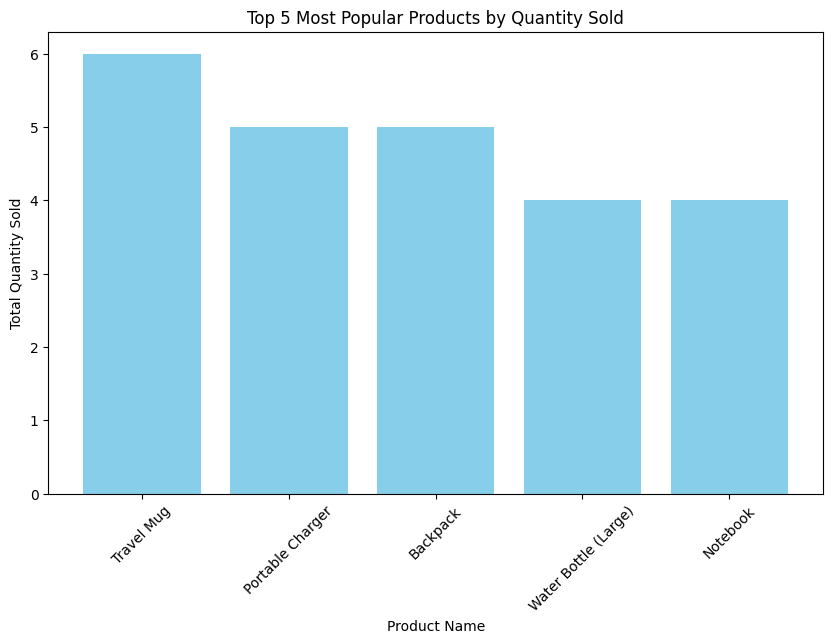

In [11]:
products = top_5_most_popular_products.select("product_name").rdd.flatMap(lambda x: x).collect()
total_quantity = top_5_most_popular_products.select("total_quantity").rdd.flatMap(lambda x: x).collect()

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(products, total_quantity, color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Sold')
plt.title('Top 5 Most Popular Products by Quantity Sold')
plt.xticks(rotation=45)
plt.show()

### Step 11: Analyze Revenue Contribution by Category

In [12]:
category_revenue = spark.sql("""
   SELECT product_name AS category, SUM(product_price * quantity) AS total_revenue
   FROM sales_table
   GROUP BY product_name
   ORDER BY total_revenue DESC
""")
category_revenue.show()

+--------------------+-----------------+
|            category|    total_revenue|
+--------------------+-----------------+
|              Laptop|           899.99|
|         Camera Lens|           899.97|
|              Tablet|           749.97|
|               Watch|           599.97|
|          Smartwatch|           399.98|
|        Air Purifier|           389.97|
|           Projector|           349.99|
| Wireless Headphones|           299.96|
|            Backpack|           249.95|
|     Fitness Tracker|           119.97|
|            Yoga Mat|           104.97|
|      Gaming Headset|            99.99|
|        Gaming Mouse|            99.98|
|          Headphones|            99.98|
|           Desk Lamp|            99.96|
|    Portable Charger|99.94999999999999|
|    Wireless Speaker|            79.99|
|          Travel Mug|            77.94|
|      Desk Organizer|            59.96|
|Water Bottle (Large)|             59.8|
+--------------------+-----------------+
only showing top

### Step 12: Visualize the Top 10 Revenue Contributions by Category Using a Bar Chart

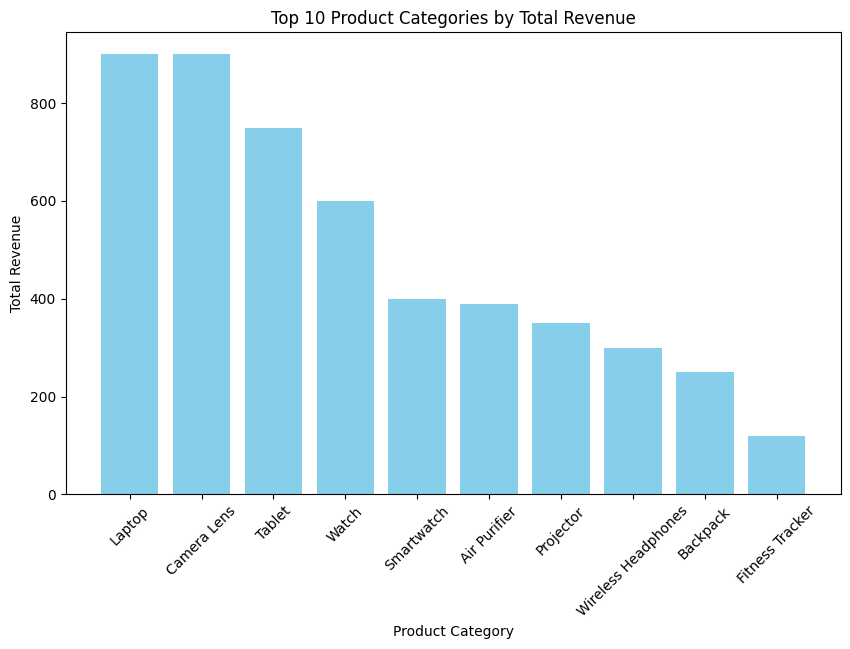

In [14]:
top_10_categories = category_revenue.limit(10)
categories = top_10_categories.select("category").rdd.flatMap(lambda x: x).collect()
revenue = top_10_categories.select("total_revenue").rdd.flatMap(lambda x: x).collect()

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(categories, revenue, color='skyblue')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.title('Top 10 Product Categories by Total Revenue')
plt.xticks(rotation=45)
plt.show()